In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import ta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM


In [2]:
df1 = pd.read_csv('AAPL.csv')

df = df1[["date", "adjOpen", 'adjHigh', 'adjLow', 'adjClose', 'adjVolume']]
df.head()

,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume
0,2015-05-27 00:00:00+00:00,120.111360,121.880685,119.844118,121.682558,45833246
1,2015-05-28 00:00:00+00:00,121.512076,121.595013,120.811718,121.438354,30733309
2,2015-05-29 00:00:00+00:00,120.931516,121.134251,119.705890,120.056069,50884452
3,2015-06-01 00:00:00+00:00,120.903870,121.078960,119.844118,120.291057,32112797
4,2015-06-02 00:00:00+00:00,119.669029,120.401640,119.171406,119.761181,33667627


In [3]:
df.tail()

,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume
1253,2020-05-18 00:00:00+00:00,313.17,316.50,310.3241,314.96,33843125
1254,2020-05-19 00:00:00+00:00,315.03,318.52,313.0100,313.14,25432385
1255,2020-05-20 00:00:00+00:00,316.68,319.52,316.2000,319.23,27876215
1256,2020-05-21 00:00:00+00:00,318.66,320.89,315.8700,316.85,25672211
1257,2020-05-22 00:00:00+00:00,315.77,319.23,315.3500,318.89,20450754


In [4]:
df.to_csv('output.csv', index=False)


In [5]:
df.shape



(1258, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       1258 non-null   object 
 1   adjOpen    1258 non-null   float64
 2   adjHigh    1258 non-null   float64
 3   adjLow     1258 non-null   float64
 4   adjClose   1258 non-null   float64
 5   adjVolume  1258 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 59.1+ KB


In [7]:
df.describe()

,adjOpen,adjHigh,adjLow,adjClose,adjVolume
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,162.493082,164.131054,161.028013,162.666715,3.500397e+07
std,58.494560,59.402842,57.869246,58.733820,1.729100e+07
min,84.634620,86.205062,84.136216,84.954351,1.136204e+07
25%,109.135002,110.393556,107.962457,109.484490,2.359205e+07
50%,154.410017,156.091874,153.054341,154.710645,3.064771e+07
75%,196.452903,198.428438,195.281553,196.960053,4.100487e+07
max,323.873661,326.357095,322.497300,326.337147,1.622063e+08


In [8]:
df.dropna()

,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume
0,2015-05-27 00:00:00+00:00,120.111360,121.880685,119.844118,121.682558,45833246
1,2015-05-28 00:00:00+00:00,121.512076,121.595013,120.811718,121.438354,30733309
2,2015-05-29 00:00:00+00:00,120.931516,121.134251,119.705890,120.056069,50884452
3,2015-06-01 00:00:00+00:00,120.903870,121.078960,119.844118,120.291057,32112797
4,2015-06-02 00:00:00+00:00,119.669029,120.401640,119.171406,119.761181,33667627
...,...,...,...,...,...,...
1253,2020-05-18 00:00:00+00:00,313.170000,316.500000,310.324100,314.960000,33843125
1254,2020-05-19 00:00:00+00:00,315.030000,318.520000,313.010000,313.140000,25432385
1255,2020-05-20 00:00:00+00:00,316.680000,319.520000,316.200000,319.230000,27876215
1256,2020-05-21 00:00:00+00:00,318.660000,320.890000,315.870000,316.850000,25672211


In [9]:
df.isna().sum()

,0
date,0
adjOpen,0
adjHigh,0
adjLow,0
adjClose,0
adjVolume,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df[df['adjHigh'] < df['adjLow']]

,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume


In [12]:
df['date_converted'] = pd.to_datetime(df['date'], errors='coerce')

invalid_dates_count = df['date_converted'].isna().sum()
print(f"Number of invalid dates: {invalid_dates_count}")



Number of invalid dates: 0


In [13]:
earliest_date = df['date_converted'].min()
latest_date = df['date_converted'].max()

print(f"The data covers a period from {earliest_date.strftime('%Y-%m-%d')} to {latest_date.strftime('%Y-%m-%d')}.")

The data covers a period from 2015-05-27 to 2020-05-22.


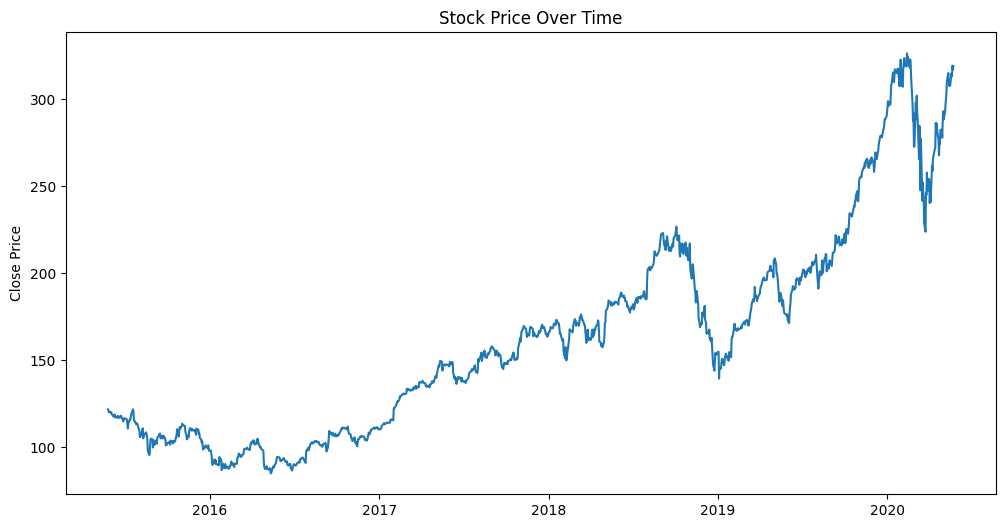

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(df['date_converted'], df['adjClose'])

plt.ylabel('Close Price')
plt.title('Stock Price Over Time')

plt.show()

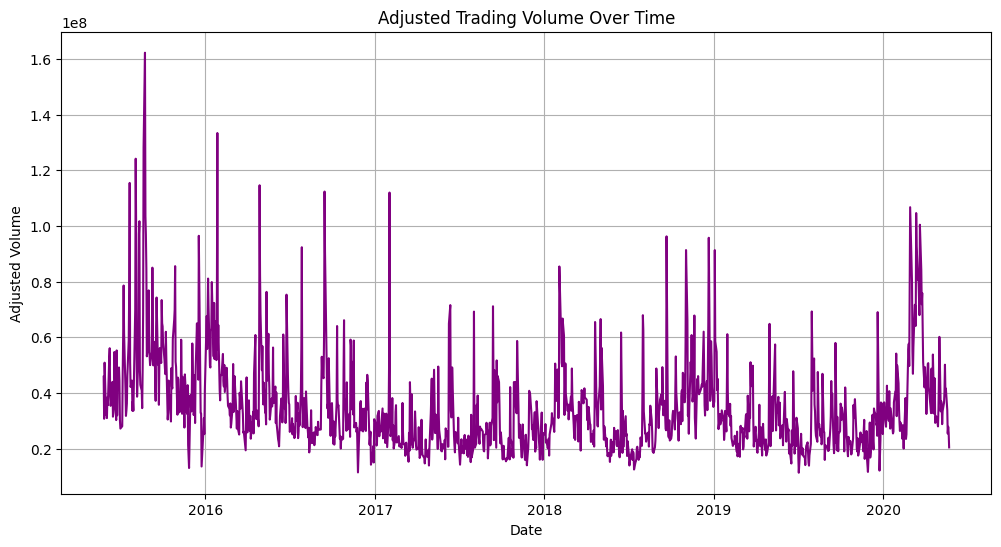

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df['date_converted'], df['adjVolume'], color='purple')
plt.xlabel('Date')
plt.ylabel('Adjusted Volume')
plt.title('Adjusted Trading Volume Over Time')
plt.grid(True)
plt.show()

In [ ]:
df.head()

,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,date_converted
0,2015-05-27 00:00:00+00:00,120.111360,121.880685,119.844118,121.682558,45833246,2015-05-27 00:00:00+00:00
1,2015-05-28 00:00:00+00:00,121.512076,121.595013,120.811718,121.438354,30733309,2015-05-28 00:00:00+00:00
2,2015-05-29 00:00:00+00:00,120.931516,121.134251,119.705890,120.056069,50884452,2015-05-29 00:00:00+00:00
3,2015-06-01 00:00:00+00:00,120.903870,121.078960,119.844118,120.291057,32112797,2015-06-01 00:00:00+00:00
4,2015-06-02 00:00:00+00:00,119.669029,120.401640,119.171406,119.761181,33667627,2015-06-02 00:00:00+00:00


In [17]:
df[df['date']!= df['date_converted']]

,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,date_converted


<Axes: xlabel='date_converted', ylabel='adjHigh'>

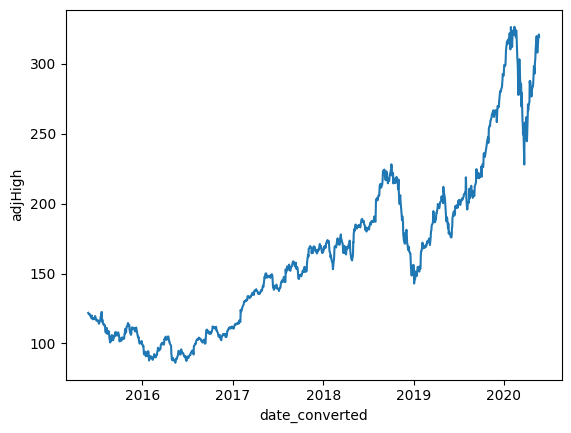

In [18]:
sns.lineplot(x='date_converted', y='adjHigh', data=df)

In [19]:
df['day_of_week'] = df['date_converted'].dt.dayofweek
df['month'] = df['date_converted'].dt.month
df.drop(axis= 1, columns= ['date'], inplace= True)

In [20]:
df.head()

,adjOpen,adjHigh,adjLow,adjClose,adjVolume,date_converted,day_of_week,month
0,120.111360,121.880685,119.844118,121.682558,45833246,2015-05-27 00:00:00+00:00,2,5
1,121.512076,121.595013,120.811718,121.438354,30733309,2015-05-28 00:00:00+00:00,3,5
2,120.931516,121.134251,119.705890,120.056069,50884452,2015-05-29 00:00:00+00:00,4,5
3,120.903870,121.078960,119.844118,120.291057,32112797,2015-06-01 00:00:00+00:00,0,6
4,119.669029,120.401640,119.171406,119.761181,33667627,2015-06-02 00:00:00+00:00,1,6


In [21]:

month_avg = df.groupby('month')['adjClose'].mean()
month_avg

,adjClose
month,
1,168.929003
2,170.816664
3,168.179459
4,174.703930
5,174.408406
6,143.704384
7,148.464470
8,154.590822
9,157.162259


In [22]:
df['year'] = df['date_converted'].dt.year
df.head()

,adjOpen,adjHigh,adjLow,adjClose,adjVolume,date_converted,day_of_week,month,year
0,120.111360,121.880685,119.844118,121.682558,45833246,2015-05-27 00:00:00+00:00,2,5,2015
1,121.512076,121.595013,120.811718,121.438354,30733309,2015-05-28 00:00:00+00:00,3,5,2015
2,120.931516,121.134251,119.705890,120.056069,50884452,2015-05-29 00:00:00+00:00,4,5,2015
3,120.903870,121.078960,119.844118,120.291057,32112797,2015-06-01 00:00:00+00:00,0,6,2015
4,119.669029,120.401640,119.171406,119.761181,33667627,2015-06-02 00:00:00+00:00,1,6,2015


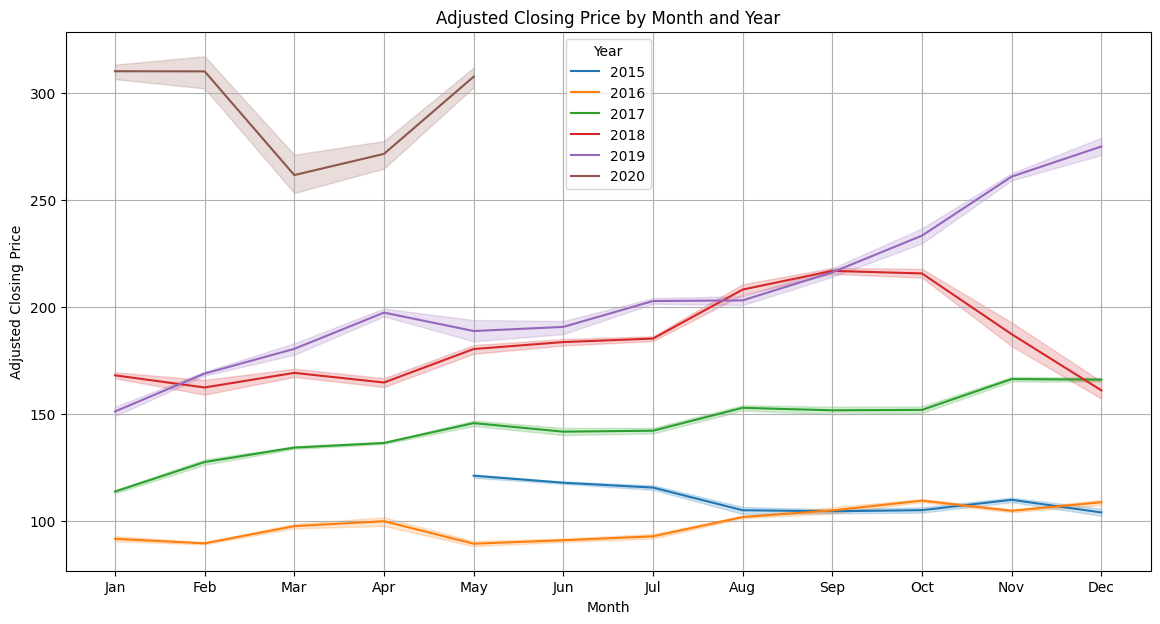

In [23]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='month', y='adjClose', hue='year', palette='tab10')
plt.title('Adjusted Closing Price by Month and Year')
plt.xlabel('Month')
plt.ylabel('Adjusted Closing Price')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.grid(True)
plt.show()

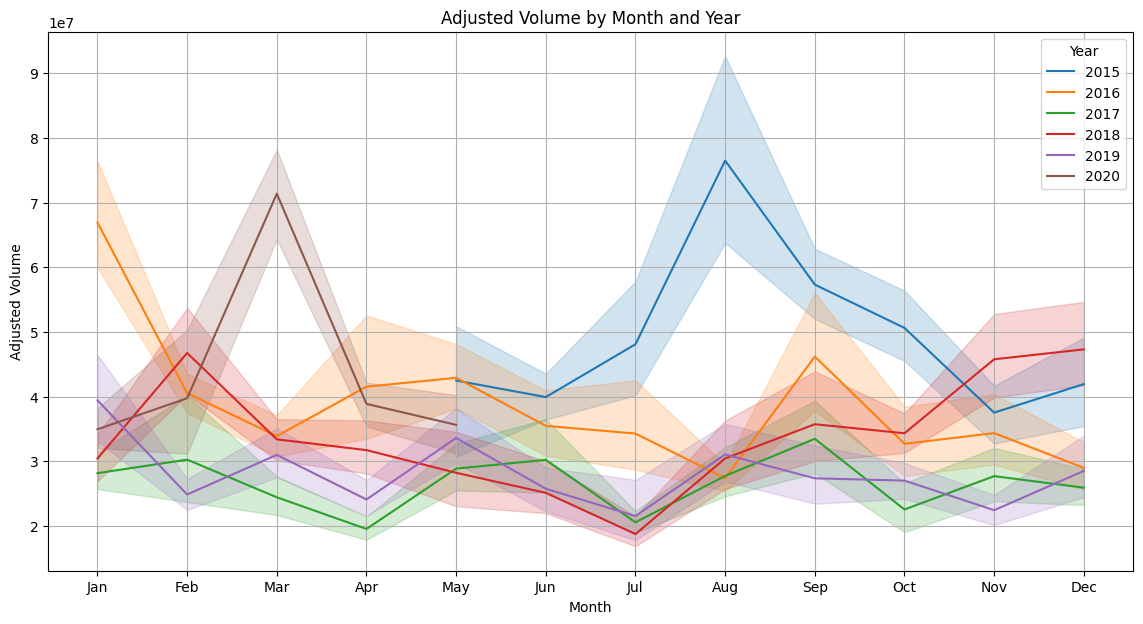

In [24]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='month', y='adjVolume', hue='year', palette='tab10')
plt.title('Adjusted Volume by Month and Year')
plt.xlabel('Month')
plt.ylabel('Adjusted Volume')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.grid(True)
plt.show()

In [25]:
df.drop(axis= 1, columns= ['date_converted'], inplace= True)

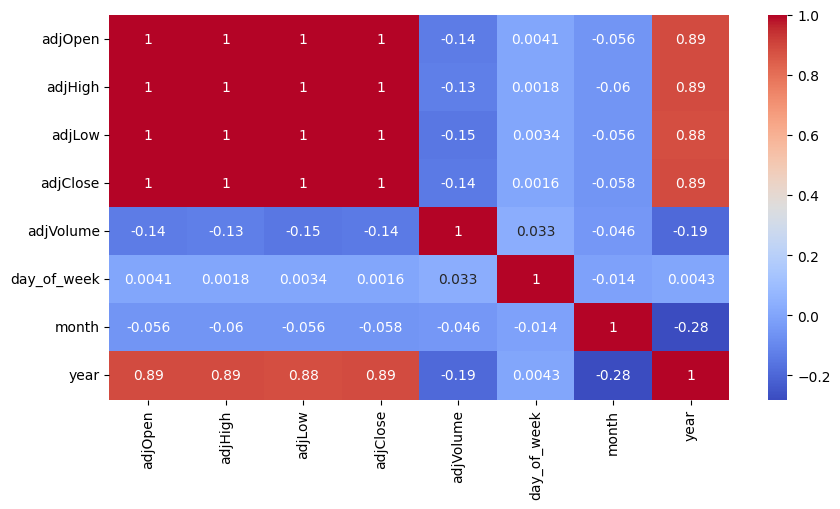

In [26]:
plt.figure(figsize=(10 ,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


In [27]:
df['SMA_10'] = df['adjClose'].rolling(10).mean()
df['SMA_50'] = df['adjClose'].rolling(50).mean()




In [28]:

df['RSI'] = ta.momentum.RSIIndicator(df['adjClose']).rsi()



In [29]:

macd = ta.trend.MACD(df['adjClose'])
df['MACD'] = macd.macd()
df['MACD_Signal'] = macd.macd_signal()


df['Target '] = df['adjClose'].shift(-1)
df.dropna(inplace= True)




In [30]:
df['MACD_hist'] = macd.macd_diff()

In [31]:
df.head(10)

,adjOpen,adjHigh,adjLow,adjClose,adjVolume,day_of_week,month,year,SMA_10,SMA_50,RSI,MACD,MACD_Signal,Target,MACD_hist
49,104.086068,108.223708,103.302773,106.343801,98384461,2,8,2015,111.591876,116.327677,28.407229,-2.353168,-1.337866,106.574181,-1.015302
50,107.351757,107.842371,105.634610,106.574181,52903040,3,8,2015,110.715508,116.025510,29.329230,-2.572309,-1.584755,106.935199,-0.987554
51,106.065054,107.610949,105.990999,106.935199,38670405,4,8,2015,109.936061,115.735447,30.832479,-2.685887,-1.804981,110.823078,-0.880906
52,107.870141,111.073013,107.870141,110.823078,54951597,0,8,2015,109.704826,115.550787,44.519292,-2.434120,-1.930809,105.056057,-0.503311
53,109.055019,109.397522,104.907947,105.056057,97082814,1,8,2015,108.840676,115.246087,33.826696,-2.669175,-2.078482,106.676007,-0.590693
54,104.167399,106.842630,101.482911,106.676007,101685610,2,8,2015,108.174460,114.984383,38.308905,-2.693690,-2.201524,106.592695,-0.492166
55,107.416555,107.749802,106.028027,106.592695,48535789,3,8,2015,107.557048,114.718065,38.165728,-2.688846,-2.298988,107.342500,-0.389858
56,105.824376,107.666490,105.537414,107.342500,42929516,4,8,2015,107.113219,114.480749,40.327326,-2.594595,-2.358109,108.453323,-0.236485
57,107.416555,108.906909,106.916685,108.453323,40884745,0,8,2015,107.044028,114.278736,43.479654,-2.402570,-2.367002,107.842371,-0.035569
58,107.777573,108.712515,107.388785,107.842371,34560708,1,8,2015,107.263921,114.080170,42.160460,-2.273481,-2.348298,106.463099,0.074816


In [32]:
from matplotlib import colors
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=2, cols=1, shared_xaxes=True)

fig.add_trace(
    go.Scatter(x=df.index, y=df['adjClose'], name='Price'),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=df.index, y=df['MACD'], name='MACD'),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=df.index, y=df['MACD_Signal'], name='Signal'),
    row=2, col=1
)

fig.add_trace(
    go.Bar(x=df.index, y=df['MACD_hist'], name='Histogram', marker_color = 'yellow'),
    row=2, col=1
)

fig.show()

In [33]:
df.drop(axis = 1, columns= ['day_of_week', 'year', 'month'], inplace= True)


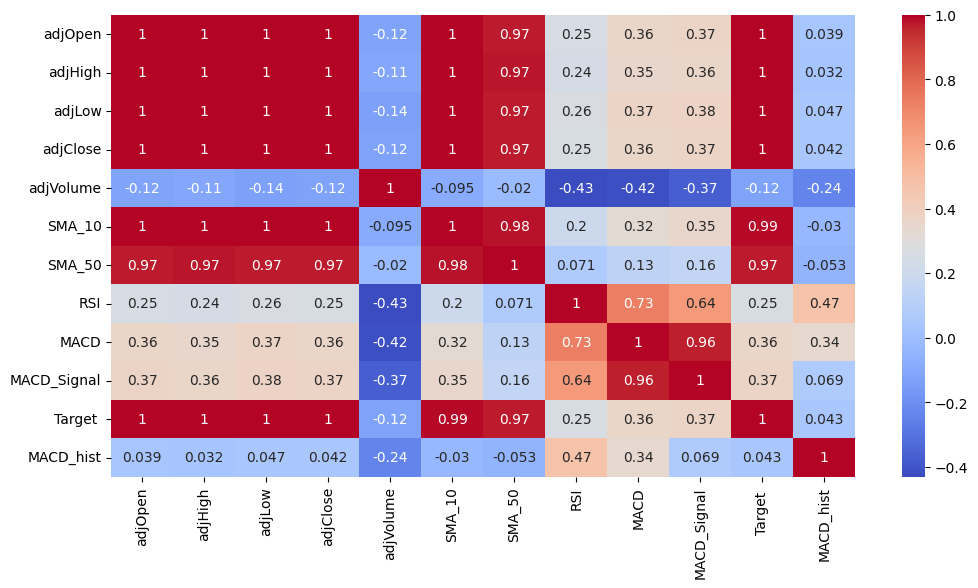

In [34]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot= True, cmap= 'coolwarm')
plt.show()

In [35]:
scaler = StandardScaler()
df = scaler.fit_transform(df)

In [36]:
df = pd.DataFrame(df)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,-1.023370,-0.966581,-1.022486,-0.984349,3.745302,-0.894258,-0.801629,-1.984207,-0.837487,-0.610196,-0.981042,-0.951817
1,-0.967794,-0.972972,-0.982368,-0.980443,1.076130,-0.909312,-0.807067,-1.918343,-0.892103,-0.675478,-0.974937,-0.926727
2,-0.989691,-0.976851,-0.976237,-0.974323,0.240858,-0.922700,-0.812287,-1.810957,-0.920410,-0.733710,-0.909187,-0.830293
3,-0.958972,-0.918827,-0.943908,-0.908414,1.196354,-0.926672,-0.815610,-0.833222,-0.857662,-0.766981,-1.006716,-0.488861
4,-0.938808,-0.946908,-0.994870,-1.006179,3.668912,-0.941516,-0.821093,-1.597061,-0.916245,-0.806029,-0.979320,-0.567874


In [37]:
x = df.drop(axis= 1, columns= [9])
y = df[9]

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [39]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f'R2 Score: {r2}')

Mean Squared Error: 5.708000675809806e-31
Mean Absolute Error: 5.8101932482722935e-16
R2 Score: 1.0


In [40]:
svm_model = SVR()
svm_model.fit(x_train, y_train)
y_pred_svm = svm_model.predict(x_test)
mse_svm = mean_squared_error(y_test, y_pred_svm)
mae_svm = mean_absolute_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)
print(f"Mean Squared Error: {mse_svm}")
print(f"Mean Absolute Error: {mae_svm}")
print(f'R2 Score: {r2_svm}')

Mean Squared Error: 0.010305839380964715
Mean Absolute Error: 0.055354425908049835
R2 Score: 0.9903358766757204


In [41]:
model_gb = GradientBoostingRegressor()
model_gb.fit(x_train, y_train)
y_pred_gb = model_gb.predict(x_test)
mse = mean_squared_error(y_test, y_pred_gb)
mae = mean_absolute_error(y_test, y_pred_gb)
r2 = r2_score(y_test, y_pred_gb)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f'R2 Score: {r2}')

Mean Squared Error: 0.005173200706650852
Mean Absolute Error: 0.046633630081292246
R2 Score: 0.9951489201643618


In [42]:
xg_model = XGBRegressor()
xg_model.fit(x_train, y_train)
y_pred_xg = xg_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred_xg)
mae = mean_absolute_error(y_test, y_pred_xg)
r2 = r2_score(y_test, y_pred_xg)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f'R2 Score: {r2}')

Mean Squared Error: 0.008098395748758777
Mean Absolute Error: 0.04849089081381809
R2 Score: 0.9924058689106505


In [43]:
model_rf = RandomForestRegressor()
model_rf.fit(x_train, y_train)
y_pred_rf = model_rf.predict(x_test)
mse = mean_squared_error(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f'R2 Score: {r2}')


Mean Squared Error: 0.012656505801613852
Mean Absolute Error: 0.051678364811905804
R2 Score: 0.9881315797384564


In [46]:
model_lstm =Sequential()
model_lstm.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model_lstm.add(LSTM(50,return_sequences=True))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))
model_lstm.compile(loss='mean_squared_error',optimizer='adam')

In [47]:
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model_lstm.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.8197 - val_loss: 0.9624
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6827 - val_loss: 0.9071
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6923 - val_loss: 0.8443
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.6967 - val_loss: 0.7399
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5233 - val_loss: 0.5757
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.5023 - val_loss: 0.5488
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3854 - val_loss: 0.4248
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3469 - val_loss: 0.3465
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3485 - val_loss: 0.3330
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.3089 - val_loss: 0.3095
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3069 - val_loss: 0.3007
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

In [52]:
y_pred_lstm = model_lstm.predict(x_test)
mse = mean_squared_error(y_test, y_pred_lstm)
mae = mean_absolute_error(y_test, y_pred_lstm)
r2 = r2_score(y_test, y_pred_lstm)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f" R2 Score: {r2}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
Mean Squared Error: 0.001347155409273239
Mean Absolute Error: 0.028726185574114865
 R2 Score: 0.9987367282245604
